In [36]:
#Import models and libraries
from DT.DecisionTree import DecisionTree
from sklearn.tree import DecisionTreeClassifier
from GNB.gaussian_naive_bayes import GNB
from LogisticRegresssion.LogisticRegression import MultiLogReg
from tensorflow import keras
from SVM.linear_svm import LinearSVMScartch
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from Kfolds import run_kfold
import itertools
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from diagnosis_curves import analysis_curves
import matplotlib.pyplot as plt




In [16]:
#Download Data
(X_train, y_train_O), (X_test, y_test) = keras.datasets.mnist.load_data()


In [17]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

In [18]:
import numpy as np
from skimage.feature import hog

def extract_hog_features(X):
    features = []

    for img in X:
        img_2d = img.reshape(28, 28)

        hog_features = hog(
            img_2d,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            feature_vector=True
        )

        features.append(hog_features)

    return np.array(features)

In [19]:
X_train_HOG = extract_hog_features(X_train)
X_test_HOG = extract_hog_features(X_test)

In [20]:
pca = PCA(n_components=50)  

X_train_hog_pca = pca.fit_transform(X_train_HOG)
X_test_hog_pca = pca.transform(X_test_HOG)

In [8]:
print(X_test_hog_pca.shape)

(10000, 50)


In [29]:
vgg_train = np.load("vgg16_gap_train.npz")
vgg_test  = np.load("vgg16_gap_test.npz")

X_train_vgg, y_train = vgg_train["X"], vgg_train["y"]
X_test_vgg, y_test   = vgg_test["X"], vgg_test["y"]

In [34]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_hog_pca, y_train_O,
    test_size=0.2,
    stratify=y_train_O,
    random_state=42
)

In [22]:
print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

(48000, 50) (12000, 50) (48000,) (12000,)


In [23]:


def manual_grid_search_DT(X, y, param_grid, k=3):

    keys = list(param_grid.keys())
    values = list(param_grid.values())

    best_score = -1
    best_params = None
    results = []

    for combo in itertools.product(*values):

        params = dict(zip(keys, combo))

        print("\nTesting:", params)

        kf = KFold(n_splits=k, shuffle=True, random_state=42)

        fold_scores = []

        for train_idx, val_idx in kf.split(X):

            X_train_fold = X[train_idx]
            X_val_fold = X[val_idx]

            y_train_fold = y[train_idx]
            y_val_fold = y[val_idx]

            model = DecisionTree(
                maxDepth=params["maxDepth"],
                minSamplesSplit=params["minSamplesSplit"],
                minSampleLeafs=params["minSampleLeafs"],
                criterion=params["criterion"],
                maxFeatures=params["maxFeatures"]
            )

            model.fit(X_train_fold, y_train_fold)

            preds = model.predict(X_val_fold)

            score = f1_score(y_val_fold, preds, average="macro")

            fold_scores.append(score)

        avg_score = sum(fold_scores) / len(fold_scores)

        print("Average score:", avg_score)

        results.append((params, avg_score))

        if avg_score > best_score:
            best_score = avg_score
            best_params = params

    print("\nBest params:", best_params)
    print("Best score:", best_score)

    return best_params, best_score, results

In [25]:
#DT hyper parameter tuning + Validation
param_grid = {
    "maxDepth": [12, 15],
    "minSamplesSplit": [5, 20],
    "minSampleLeafs": [5, 20],
    "criterion": ["gini"],
    "maxFeatures": ["sqrt"]
}
best_params, _, _ = manual_grid_search_DT(X_train_HOG , y_train_O , param_grid)




Testing: {'maxDepth': 12, 'minSamplesSplit': 5, 'minSampleLeafs': 5, 'criterion': 'gini', 'maxFeatures': 'sqrt'}
Average score: 0.7950246111439748

Testing: {'maxDepth': 12, 'minSamplesSplit': 5, 'minSampleLeafs': 20, 'criterion': 'gini', 'maxFeatures': 'sqrt'}
Average score: 0.7926895761140674

Testing: {'maxDepth': 12, 'minSamplesSplit': 20, 'minSampleLeafs': 5, 'criterion': 'gini', 'maxFeatures': 'sqrt'}
Average score: 0.799396424419307

Testing: {'maxDepth': 12, 'minSamplesSplit': 20, 'minSampleLeafs': 20, 'criterion': 'gini', 'maxFeatures': 'sqrt'}
Average score: 0.7973744955550516

Testing: {'maxDepth': 15, 'minSamplesSplit': 5, 'minSampleLeafs': 5, 'criterion': 'gini', 'maxFeatures': 'sqrt'}
Average score: 0.8198144970051658

Testing: {'maxDepth': 15, 'minSamplesSplit': 5, 'minSampleLeafs': 20, 'criterion': 'gini', 'maxFeatures': 'sqrt'}
Average score: 0.7984652723605574

Testing: {'maxDepth': 15, 'minSamplesSplit': 20, 'minSampleLeafs': 5, 'criterion': 'gini', 'maxFeatures': '

In [27]:
#Decision tree
#Best params from Grid search =>{'maxDepth': 15, 'minSamplesSplit': 20, 'minSampleLeafs': 5, 'criterion': 'gini', 'maxFeatures': 'sqrt'}

dt = DecisionTree(**best_params)

dt.fit(X_train_HOG , y_train_O)
predictions = dt.predict(X_test_HOG)
print(classification_report(
    y_test, predictions,
))



              precision    recall  f1-score   support

           0       0.85      0.90      0.87       980
           1       0.96      0.94      0.95      1135
           2       0.84      0.84      0.84      1032
           3       0.79      0.80      0.79      1010
           4       0.83      0.84      0.84       982
           5       0.84      0.81      0.82       892
           6       0.91      0.87      0.89       958
           7       0.83      0.84      0.84      1028
           8       0.78      0.76      0.77       974
           9       0.81      0.83      0.82      1009

    accuracy                           0.85     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.85      0.85      0.85     10000



In [30]:
#Decision Tree CNN results
dt = DecisionTree(**best_params)

dt.fit(X_train_vgg , y_train_O)
predictions = dt.predict(X_test_vgg)
print(classification_report(
    y_test, predictions,
))



              precision    recall  f1-score   support

           0       0.84      0.86      0.85       980
           1       0.95      0.95      0.95      1135
           2       0.63      0.63      0.63      1032
           3       0.69      0.76      0.73      1010
           4       0.80      0.78      0.79       982
           5       0.63      0.63      0.63       892
           6       0.75      0.74      0.74       958
           7       0.78      0.78      0.78      1028
           8       0.80      0.77      0.79       974
           9       0.80      0.75      0.77      1009

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



Starting Decision Tree Learning Curve evaluations...

--- Running Evaluation 1/2: ACCURACY ---
Size 20/60000 -> Train: 0.4000 | Val: 0.1746
Size 8588/60000 -> Train: 0.8775 | Val: 0.7679
Size 17157/60000 -> Train: 0.8903 | Val: 0.8048
Size 25725/60000 -> Train: 0.8953 | Val: 0.8098
Size 34294/60000 -> Train: 0.9034 | Val: 0.8218
Size 42862/60000 -> Train: 0.9046 | Val: 0.8230
Size 51431/60000 -> Train: 0.9096 | Val: 0.8410
Size 60000/60000 -> Train: 0.9137 | Val: 0.8491


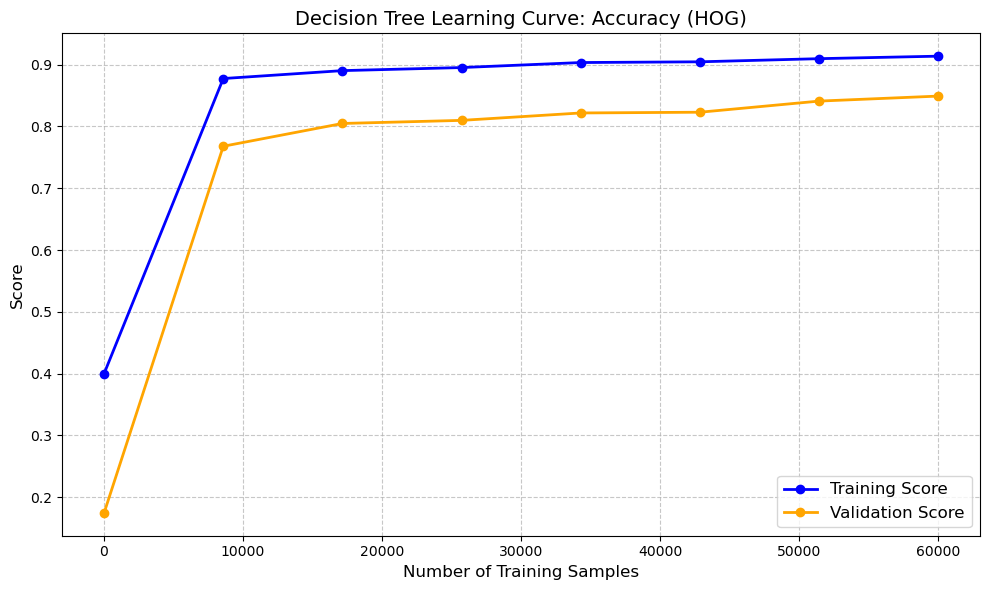


--- Running Evaluation 2/2: MACRO F1-SCORE ---
Size 20/60000 -> Train: 0.1548 | Val: 0.0532
Size 8588/60000 -> Train: 0.8763 | Val: 0.7666
Size 17157/60000 -> Train: 0.8836 | Val: 0.7862
Size 25725/60000 -> Train: 0.8973 | Val: 0.8195
Size 34294/60000 -> Train: 0.9051 | Val: 0.8173
Size 42862/60000 -> Train: 0.9064 | Val: 0.8308
Size 51431/60000 -> Train: 0.9084 | Val: 0.8344
Size 60000/60000 -> Train: 0.9130 | Val: 0.8474


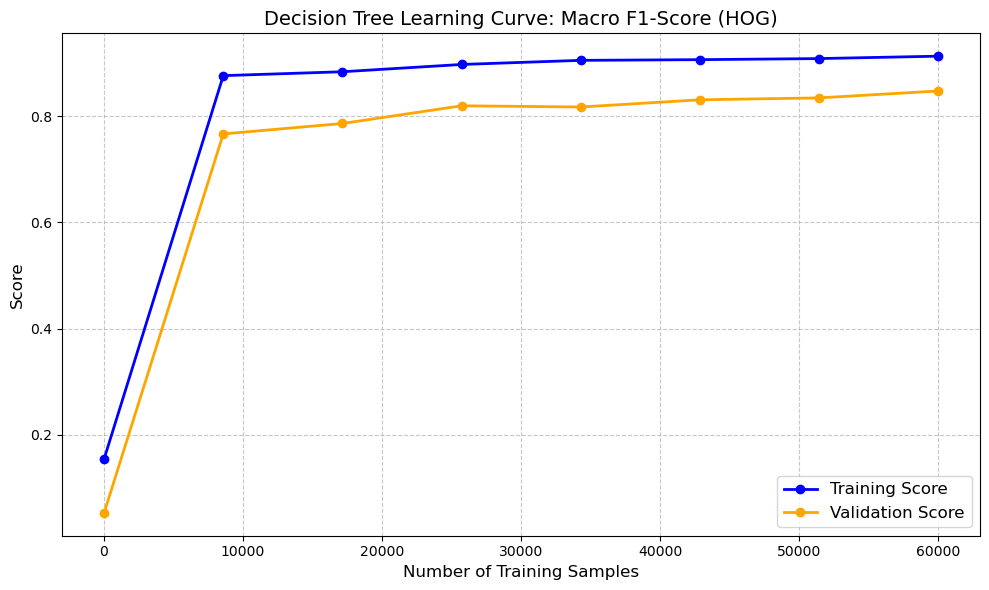

In [31]:
#Decision Tree overfitting underfitting analysis
print("Starting Decision Tree Learning Curve evaluations...\n")

def train_dt_hog(X_subset, y_subset):
    model = DecisionTree(
        maxDepth=15,
        minSamplesSplit=20,
        minSampleLeafs=1,
        criterion="entropy",
        maxFeatures="sqrt",
        randomState=42
    )
    model.fit(X_subset, y_subset)
    return model

def predict_dt_hog(model, X):
    return model.predict(X)

def metric_acc(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

def metric_f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")


print("--- Running Evaluation 1/2: ACCURACY ---")
subset_sizes_acc, train_trends_acc, val_trends_acc = analysis_curves(
    X_train=X_train_HOG,
    y_train=y_train_O,
    X_val=X_test_HOG,
    y_val=y_test,
    train_fn=train_dt_hog,
    predict_fn=predict_dt_hog,
    metric_fn=metric_acc,
    num_steps=8,
    title="Decision Tree Learning Curve: Accuracy (HOG)"
)


print("\n--- Running Evaluation 2/2: MACRO F1-SCORE ---")
subset_sizes_f1, train_trends_f1, val_trends_f1 = analysis_curves(
    X_train=X_train_HOG,
    y_train=y_train_O,
    X_val=X_test_HOG,
    y_val=y_test,
    train_fn=train_dt_hog,
    predict_fn=predict_dt_hog,
    metric_fn=metric_f1_macro,
    num_steps=8,
    title="Decision Tree Learning Curve: Macro F1-Score (HOG)"
)



HOG + PCA

=== K-FOLD VALIDATION ===
Fold 1 → F1: 0.9277
Fold 2 → F1: 0.9309
Fold 3 → F1: 0.9298
Fold 4 → F1: 0.9330
Fold 5 → F1: 0.9354

K-Fold Avg F1: 0.9313638348117264

=== TEST RESULTS ===
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       980
           1       0.99      0.96      0.97      1135
           2       0.93      0.95      0.94      1032
           3       0.93      0.94      0.94      1010
           4       0.95      0.95      0.95       982
           5       0.95      0.92      0.94       892
           6       0.97      0.94      0.96       958
           7       0.96      0.89      0.92      1028
           8       0.86      0.93      0.89       974
           9       0.90      0.92      0.91      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



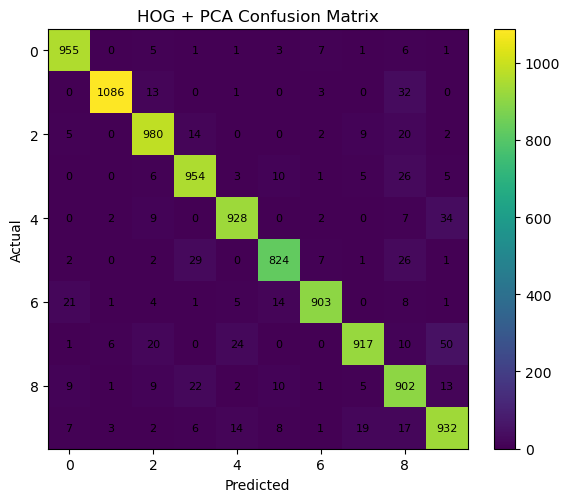


VGG (RAW)

=== K-FOLD VALIDATION ===
Fold 1 → F1: 0.8613
Fold 2 → F1: 0.8681
Fold 3 → F1: 0.8643
Fold 4 → F1: 0.8580
Fold 5 → F1: 0.8606

K-Fold Avg F1: 0.862471802050865

=== TEST RESULTS ===
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       980
           1       0.99      0.94      0.97      1135
           2       0.81      0.64      0.71      1032
           3       0.76      0.90      0.82      1010
           4       0.90      0.92      0.91       982
           5       0.71      0.73      0.72       892
           6       0.93      0.86      0.89       958
           7       0.86      0.89      0.87      1028
           8       0.88      0.94      0.91       974
           9       0.90      0.90      0.90      1009

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



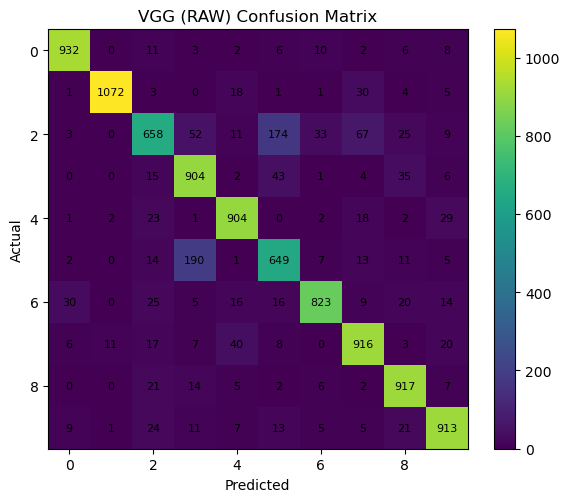


VGG + PCA (50)

=== K-FOLD VALIDATION ===
Fold 1 → F1: 0.8729
Fold 2 → F1: 0.8718
Fold 3 → F1: 0.8690
Fold 4 → F1: 0.8673
Fold 5 → F1: 0.8687

K-Fold Avg F1: 0.8699495597204253

=== TEST RESULTS ===
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       980
           1       0.95      0.93      0.94      1135
           2       0.82      0.74      0.78      1032
           3       0.86      0.88      0.87      1010
           4       0.93      0.94      0.93       982
           5       0.80      0.82      0.81       892
           6       0.94      0.88      0.91       958
           7       0.82      0.84      0.83      1028
           8       0.81      0.90      0.85       974
           9       0.92      0.89      0.91      1009

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



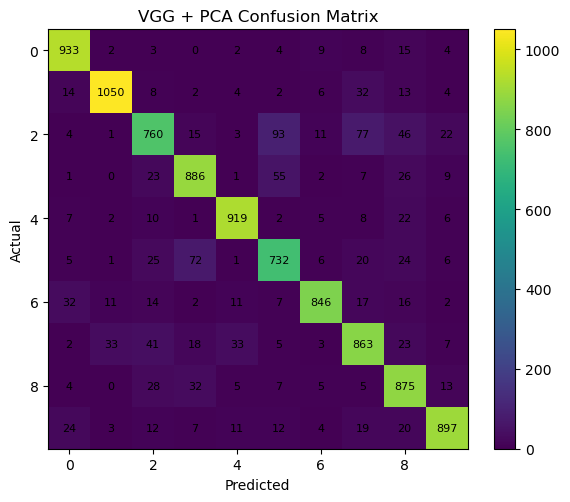

Size 20/60000 -> Train: 1.0000 | Val: 0.1585
Size 8588/60000 -> Train: 0.9332 | Val: 0.9350
Size 17157/60000 -> Train: 0.9320 | Val: 0.9371
Size 25725/60000 -> Train: 0.9312 | Val: 0.9374
Size 34294/60000 -> Train: 0.9315 | Val: 0.9382
Size 42862/60000 -> Train: 0.9315 | Val: 0.9379
Size 51431/60000 -> Train: 0.9317 | Val: 0.9376
Size 60000/60000 -> Train: 0.9316 | Val: 0.9380


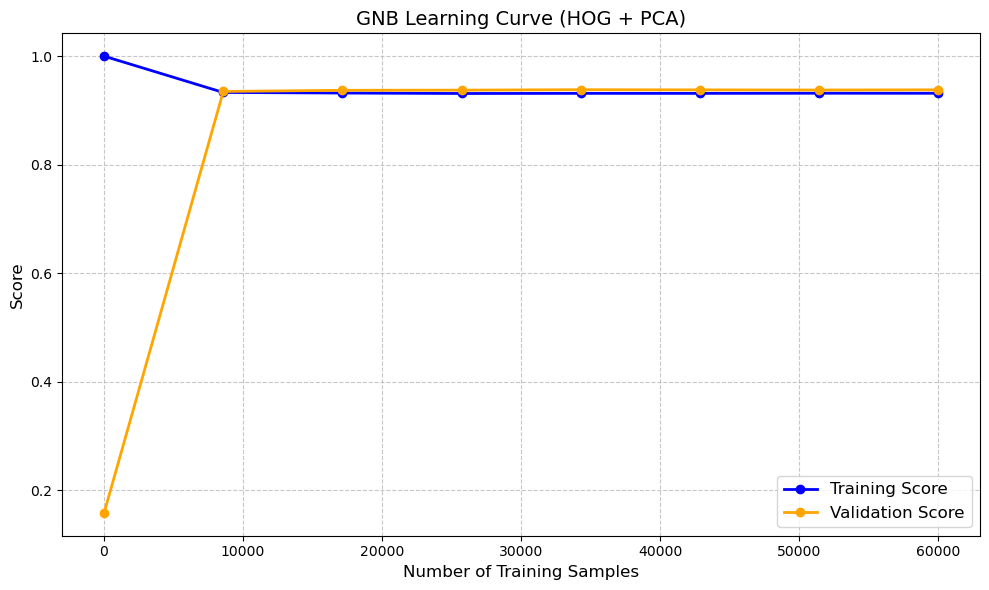

Size 20/60000 -> Train: 1.0000 | Val: 0.0975
Size 8588/60000 -> Train: 0.9373 | Val: 0.9370
Size 17157/60000 -> Train: 0.9330 | Val: 0.9376
Size 25725/60000 -> Train: 0.9320 | Val: 0.9370
Size 34294/60000 -> Train: 0.9313 | Val: 0.9369
Size 42862/60000 -> Train: 0.9313 | Val: 0.9372
Size 51431/60000 -> Train: 0.9310 | Val: 0.9371
Size 60000/60000 -> Train: 0.9315 | Val: 0.9379


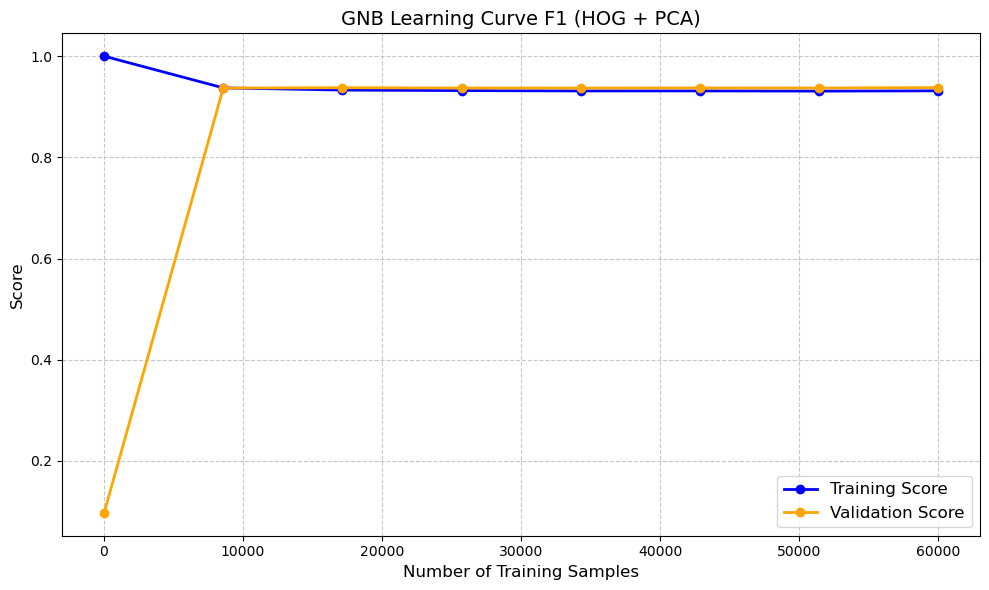

(array([   20,  8588, 17157, 25725, 34294, 42862, 51431, 60000]),
 [1.0,
  0.9373315975862564,
  0.9329825219578278,
  0.931981676257311,
  0.9312650617846924,
  0.9313403997979446,
  0.9309533760802664,
  0.9315123137923974],
 [0.09746238225087064,
  0.9370446802657174,
  0.9376014884687054,
  0.9370364883999758,
  0.936935861406168,
  0.9371748126496191,
  0.9370829383838288,
  0.9378892050417699])

In [37]:

# ======================
# Helper Functions
# ======================
def train_gnb(X, y):
    gnb = GNB()
    gnb.gaussian_naive_train(X, y)
    return gnb

def predict_gnb(model, X):
    return model.predict(X)

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()


# ======================
# HOG + PCA (YOUR ORIGINAL)
# ======================
print("\n==============================")
print("HOG + PCA")
print("==============================")

print("\n=== K-FOLD VALIDATION ===")
run_kfold(X_train, y_train, train_gnb, predict_gnb, k=5, binary=0)

gnb = GNB()
gnb.gaussian_naive_train(X_train, y_train)

predictions_hog = gnb.predict(X_test_hog_pca)

print("\n=== TEST RESULTS ===")
print(classification_report(y_test, predictions_hog))

plot_cm(y_test, predictions_hog, "HOG + PCA Confusion Matrix")


# ======================
# LOAD VGG FEATURES
# ======================
vgg_train = np.load("vgg16_gap_train.npz")
vgg_test  = np.load("vgg16_gap_test.npz")

X_train_vgg, y_train = vgg_train["X"], vgg_train["y"]
X_test_vgg, y_test   = vgg_test["X"], vgg_test["y"]


# ======================
# VGG (RAW)
# ======================
print("\n==============================")
print("VGG (RAW)")
print("==============================")

print("\n=== K-FOLD VALIDATION ===")
run_kfold(X_train_vgg, y_train, train_gnb, predict_gnb, k=5, binary=0)

gnb = GNB()
gnb.gaussian_naive_train(X_train_vgg, y_train)

predictions_vgg = gnb.predict(X_test_vgg)

print("\n=== TEST RESULTS ===")
print(classification_report(y_test, predictions_vgg))

plot_cm(y_test, predictions_vgg, "VGG (RAW) Confusion Matrix")


# ======================
# VGG + PCA (50)
# ======================
print("\n==============================")
print("VGG + PCA (50)")
print("==============================")

pca = PCA(n_components=50)

X_train_vgg_pca = pca.fit_transform(X_train_vgg)
X_test_vgg_pca = pca.transform(X_test_vgg)

print("\n=== K-FOLD VALIDATION ===")
run_kfold(X_train_vgg_pca, y_train, train_gnb, predict_gnb, k=5, binary=0)

gnb = GNB()
gnb.gaussian_naive_train(X_train_vgg_pca, y_train)

predictions_vgg_pca = gnb.predict(X_test_vgg_pca)

print("\n=== TEST RESULTS ===")
print(classification_report(y_test, predictions_vgg_pca))

plot_cm(y_test, predictions_vgg_pca, "VGG + PCA Confusion Matrix")
from sklearn.metrics import accuracy_score

# metric
def metric_fn(y_true, y_pred):
    return accuracy_score(y_true, y_pred)
def metric_f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')

# run analysis
analysis_curves(
    X_train_hog_pca,
    y_train,
    X_test_hog_pca,   # using test as validation
    y_test,
    train_fn=train_gnb,
    predict_fn=predict_gnb,
    metric_fn=metric_fn,
    num_steps=8,
    title="GNB Learning Curve (HOG + PCA)"
)
analysis_curves(
    X_train_hog_pca,
    y_train,
    X_test_hog_pca,   # using test as validation
    y_test,
    train_fn=train_gnb,
    predict_fn=predict_gnb,
    metric_fn=metric_f1_macro,
    num_steps=8,
    title="GNB Learning Curve F1 (HOG + PCA)"
)

In [ ]:
from GridSearches import gridSearchLog

param_grid = {
    'max_iterations': [100, 500, 1000],
    'learning_rate': [0.01, 0.1, 0.5],
    'class_weight': [None, 'balanced'],
    'reg_eqn': [None, 'L1', 'L2'],
    'reg_param': [0.01, 0.1, 1.0, 10],
    'random_state': [42]
}
x_train_vgg_log = np.load(r"D:\Moaz\Saphone\ML\Machine-Learning-Number-Classification_MNIST\vgg16_gap_train.npz\X.npy")


configs = {
    "HOG": X_train_HOG,
    "VGG": x_train_vgg_log
}

print("\nStarting GPU-Accelerated Grid Search (50 Features)...")
final_comparison = {}

for name, data in configs.items():
    print(f"\n" + "="*60)
    print(f"SEARCHING: {name} | Features: {data.shape[1]}")
    print("="*60)

    best_params, best_score, _ = gridSearchLog(data, y_train, param_grid, k_cross=3)
    final_comparison[name] = {"Score": best_score, "Params": best_params}

print("\n" + "#"*60)
print("FINAL GPU CHAMPION MODELS")
print("#"*60)
for name, res in final_comparison.items():
    print(f"{name:15} | Macro F1: {res['Score']:.4f}")
    print(f"Optimal Params: {res['Params']}\n")

In [12]:
import numpy as np
from LogisticRegresssion.LogisticRegression import MultiLogReg
from sklearn.metrics import classification_report

hogLog = MultiLogReg(max_iterations=500, learning_rate=0.5, class_weight=None, reg_eqn='L2', reg_param=1.0, random_state=42)

hogLog.fit(X_train_HOG, y_train)
hogLog_preds = hogLog.predict(X_test_HOG)

print(classification_report(y_test, hogLog_preds))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       980
           1       0.98      0.99      0.99      1135
           2       0.96      0.96      0.96      1032
           3       0.98      0.97      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.97      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.96      1028
           8       0.94      0.94      0.94       974
           9       0.96      0.95      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [18]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, hogLog_preds))

[[ 967    0    4    0    0    1    3    1    3    1]
 [   0 1125    4    1    0    1    2    0    2    0]
 [   9    2  995    0    1    0    3    8   14    0]
 [   0    0    3  975    0   11    1    7   10    3]
 [   2    3    1    0  956    0    2    1    4   13]
 [   2    1    2    9    0  866    6    0    5    1]
 [   6    3    0    0    3    8  935    0    3    0]
 [   0    8   14    0    5    0    0  985    3   13]
 [  13    1    7    8    4    3    2    6  917   13]
 [   5    6    2    4    9    3    0   10   10  960]]


In [ ]:
import numpy as np
from LogisticRegresssion.LogisticRegression import MultiLogReg
from sklearn.metrics import classification_report

x_train_vgg_log = np.load(r"D:\Moaz\Saphone\ML\Machine-Learning-Number-Classification_MNIST\vgg16_gap_train.npz\X.npy")
y_train_vgg_log = np.load(r"D:\Moaz\Saphone\ML\Machine-Learning-Number-Classification_MNIST\vgg16_gap_train.npz\y.npy")

x_test_vgg_log = np.load(r"D:\Moaz\Saphone\ML\Machine-Learning-Number-Classification_MNIST\vgg16_gap_test.npz\X.npy")
y_test_vgg_log = np.load(r"D:\Moaz\Saphone\ML\Machine-Learning-Number-Classification_MNIST\vgg16_gap_test.npz\y.npy")

finalLog = MultiLogReg(max_iterations=1000, learning_rate=0.1, class_weight=None, reg_eqn='L2', reg_param=10, random_state=42)

finalLog.fit(x_train_vgg_log, y_train_vgg_log)
finalLog_preds = finalLog.predict(x_test_vgg_log)

print(classification_report(y_test_vgg_log, finalLog_preds))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.95      0.95      0.95      1032
           3       0.95      0.97      0.96      1010
           4       0.98      0.98      0.98       982
           5       0.95      0.94      0.94       892
           6       0.98      0.97      0.98       958
           7       0.96      0.97      0.96      1028
           8       0.98      0.98      0.98       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [22]:
print(X_train_HOG.shape)

(60000, 1296)


In [19]:
print(confusion_matrix(y_test_vgg_log, finalLog_preds))

[[ 964    0    2    0    1    0    5    3    1    4]
 [   1 1127    2    0    0    0    0    5    0    0]
 [   2    1  977    9    1   18    5   11    3    5]
 [   0    0    8  975    0   18    0    4    3    2]
 [   0    3    1    1  960    1    3    3    2    8]
 [   1    0   17   22    1  838    4    5    2    2]
 [   9    1    2    1    6    5  931    0    2    1]
 [   1    4   10    3    7    2    1  994    0    6]
 [   2    0    4    9    0    0    2    2  951    4]
 [   3    0    7    1    5    4    0   10    6  973]]


Size 20/48000 -> Train: 1.0000 | Val: 0.3930
Size 6874/48000 -> Train: 0.9732 | Val: 0.9663
Size 13728/48000 -> Train: 0.9679 | Val: 0.9672
Size 20582/48000 -> Train: 0.9667 | Val: 0.9677
Size 27437/48000 -> Train: 0.9651 | Val: 0.9678
Size 34291/48000 -> Train: 0.9647 | Val: 0.9678
Size 41145/48000 -> Train: 0.9648 | Val: 0.9675
Size 48000/48000 -> Train: 0.9646 | Val: 0.9676


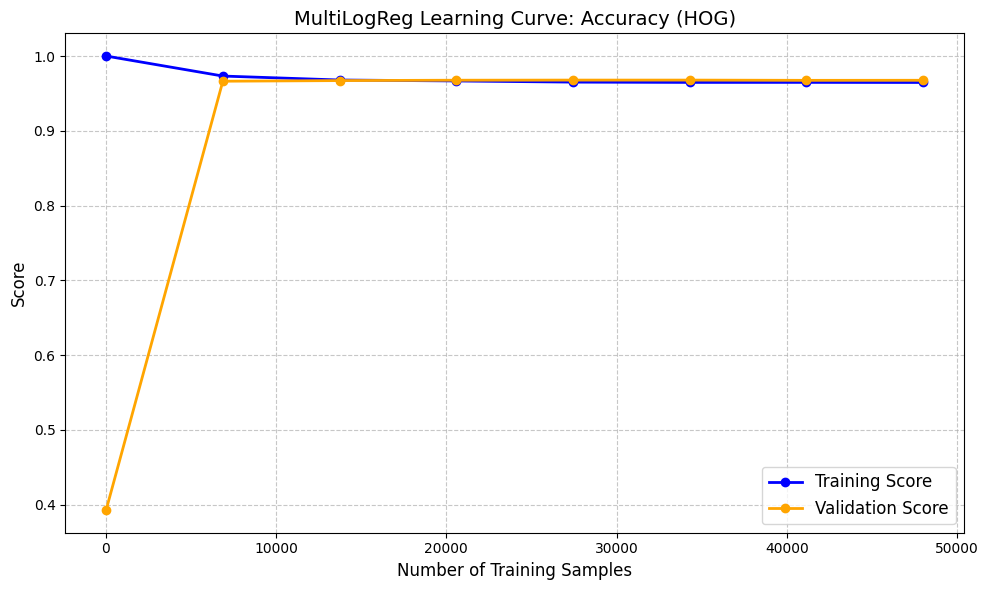

Size 20/48000 -> Train: 1.0000 | Val: 0.3128
Size 6874/48000 -> Train: 0.9622 | Val: 0.9595
Size 13728/48000 -> Train: 0.9569 | Val: 0.9609
Size 20582/48000 -> Train: 0.9569 | Val: 0.9611


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import accuracy_score

X_train1 = X_train_HOG[:48000]
y_train1 = y_train[:48000]
X_val1 = X_train_HOG[48000:]
y_val1 = y_train[48000:]



def train_multilogreg_hog(X_subset, y_subset):
    model = MultiLogReg(max_iterations=500, learning_rate=0.5, class_weight=None, reg_eqn='L2', reg_param=1.0, random_state=42)
    model.fit(X_subset, y_subset)
    return model


def predict_multilogreg(model, X):
    return model.predict(X)

def metric_acc(y_true, y_pred):
    return accuracy_score(y_true, y_pred)


subset_sizes_acc, train_trends_acc, val_trends_acc = analysis_curves(
    X_train=X_train1, 
    y_train=y_train1, 
    X_val=X_val1, 
    y_val=y_val1, 
    train_fn=train_multilogreg_hog, 
    predict_fn=predict_multilogreg, 
    metric_fn=metric_acc, 
    num_steps=8,
    title="MultiLogReg Learning Curve: Accuracy (HOG)"
)




Size 20/48000 -> Train: 1.0000 | Val: 0.3641
Size 6874/48000 -> Train: 0.9875 | Val: 0.9603
Size 13728/48000 -> Train: 0.9710 | Val: 0.9630
Size 20582/48000 -> Train: 0.9782 | Val: 0.9698
Size 27437/48000 -> Train: 0.9747 | Val: 0.9673
Size 34291/48000 -> Train: 0.9754 | Val: 0.9695
Size 41145/48000 -> Train: 0.9736 | Val: 0.9692
Size 48000/48000 -> Train: 0.9743 | Val: 0.9703


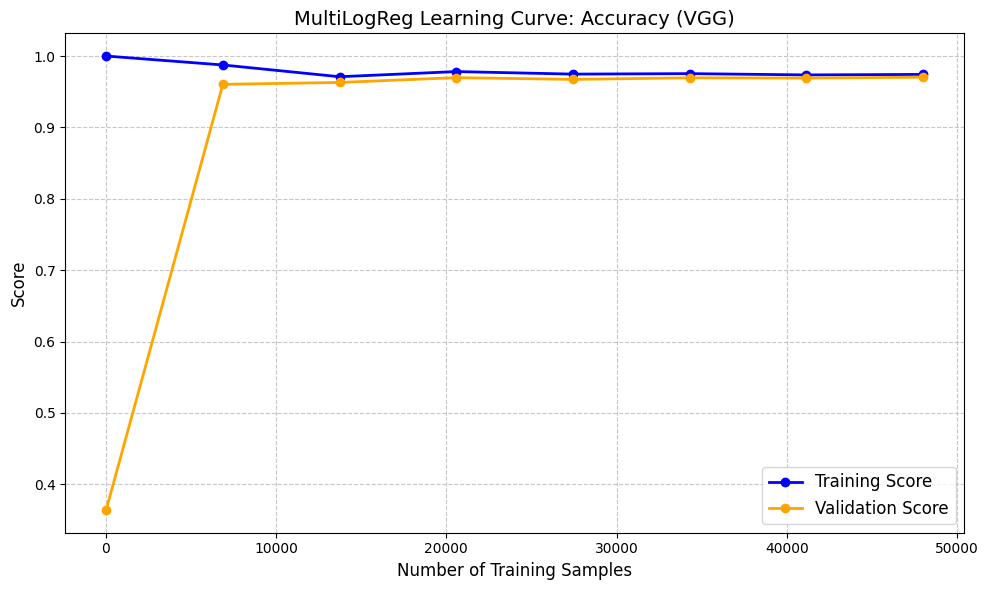

In [21]:
X_train2 = x_train_vgg_log[:48000]
y_train2 = y_train_vgg_log[:48000]
X_val2 = x_train_vgg_log[48000:]
y_val2 = y_train_vgg_log[48000:]

def train_multilogreg_vgg(X_subset, y_subset):
    model = MultiLogReg(max_iterations=1000, learning_rate=0.1, class_weight=None, reg_eqn='L2', reg_param=10, random_state=42)
    model.fit(X_subset, y_subset)
    return model

def predict_multilogreg(model, X):
    return model.predict(X)

def metric_acc(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

subset_sizes_f1, train_trends_f1, val_trends_f1 = analysis_curves(
    X_train=X_train2, 
    y_train=y_train2, 
    X_val=X_val2, 
    y_val=y_val2, 
    train_fn=train_multilogreg_vgg, 
    predict_fn=predict_multilogreg, 
    metric_fn=metric_acc, 
    num_steps=8,
    title="MultiLogReg Learning Curve: Accuracy (VGG)"
)

In [23]:
import pickle
model_filename = 'multiLog_hog.pkl'
print(f"\nSaving model to {model_filename}...")
with open(model_filename, 'wb') as file:
    pickle.dump(hogLog, file)
print("Model saved successfully!")


Saving model to multiLog_hog.pkl...
Model saved successfully!


In [2]:
#Import models and libraries
from DT.DecisionTree import DecisionTree
from sklearn.tree import DecisionTreeClassifier
#from GNB.gaussian_naive_bayes import GNB
#from LogisticRegresssion.LogisticRegression import MultiLogReg
from tensorflow import keras
from SVM.linear_svm import LinearSVMScartch
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from Kfolds import run_kfold
import itertools
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from diagnosis_curves import analysis_curves



In [6]:
X_train.shape

(60000, 28, 28)

In [8]:

# ============================================================
# MultiClass SVM — Setup: imports, grid search, all 3 splits
# ============================================================
from SVM.multiclass_svm import MultiClassSVMScratch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

RANDOM_STATE = 42

# Reload original y_train (60000) in case it was overwritten by earlier split cells
(_, y_train_orig), (_, _) = keras.datasets.mnist.load_data()

def manual_grid_search_SVM(X_tr, y_tr, X_v, y_v, label=''):
    C_values  = [0.1, 1.0, 10.0]
    lr_values = [0.001, 0.0005, 0.0001]
    print(f"{'C':>6}  {'LR':>8}  {'Val Acc':>9}")
    print("-" * 30)
    results = []
    for C in C_values:
        for lr in lr_values:
            model = MultiClassSVMScratch(C=C, learning_rate=lr,
                                         n_epochs=30, random_state=RANDOM_STATE)
            model.fit(X_tr, y_tr)
            acc = accuracy_score(y_v, model.predict(X_v))
            results.append((C, lr, acc))
            print(f"{C:>6}  {lr:>8}  {acc:>9.4f}")
    best = max(results, key=lambda x: x[2])
    print(f"\nBest: C={best[0]}, lr={best[1]}, Val Acc={best[2]:.4f}")
    return best[0], best[1]

# ---------- Split 1: HOG only ----------
scaler_hog = StandardScaler()
X_hog_s      = scaler_hog.fit_transform(X_train_HOG)
X_test_hog_s = scaler_hog.transform(X_test_HOG)

X_tr_hog, X_v_hog, y_tr_hog, y_v_hog = train_test_split(
    X_hog_s, y_train_orig, test_size=0.2, stratify=y_train_orig, random_state=RANDOM_STATE)

# ---------- Split 2: PCA only (raw pixels) ----------
X_flat      = X_train.reshape(X_train.shape[0], -1)   # (60000, 784)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

scaler_raw   = StandardScaler()
X_flat_s     = scaler_raw.fit_transform(X_flat)
X_test_flat_s = scaler_raw.transform(X_test_flat)

pca_only      = PCA(n_components=50, random_state=RANDOM_STATE)
X_pca         = pca_only.fit_transform(X_flat_s)
X_test_pca    = pca_only.transform(X_test_flat_s)

X_tr_pca, X_v_pca, y_tr_pca, y_v_pca = train_test_split(
    X_pca, y_train_orig, test_size=0.2, stratify=y_train_orig, random_state=RANDOM_STATE)

# ---------- Split 3: HOG + PCA ----------
pca_hog       = PCA(n_components=50, random_state=RANDOM_STATE)
X_hog_pca     = pca_hog.fit_transform(X_hog_s)
X_test_hog_pca_svm = pca_hog.transform(X_test_hog_s)

X_tr_hog_pca, X_v_hog_pca, y_tr_hog_pca, y_v_hog_pca = train_test_split(
    X_hog_pca, y_train_orig, test_size=0.2, stratify=y_train_orig, random_state=RANDOM_STATE)

print(f"HOG only  — Train: {X_tr_hog.shape},     Test: {X_test_hog_s.shape}")
print(f"PCA only  — Train: {X_tr_pca.shape},      Test: {X_test_pca.shape}")
print(f"HOG+PCA   — Train: {X_tr_hog_pca.shape},  Test: {X_test_hog_pca_svm.shape}")


HOG only  — Train: (48000, 1296),     Test: (10000, 1296)
PCA only  — Train: (48000, 50),      Test: (10000, 50)
HOG+PCA   — Train: (48000, 50),  Test: (10000, 50)


In [9]:

# ============================================================
# MultiClass SVM — HOG only
# ============================================================
print("=== MultiClass SVM: HOG only ===\n")
best_C, best_lr = manual_grid_search_SVM(X_tr_hog, y_tr_hog, X_v_hog, y_v_hog)

svm_hog = MultiClassSVMScratch(C=best_C, learning_rate=best_lr,
                                n_epochs=50, random_state=RANDOM_STATE)
svm_hog.fit(X_tr_hog, y_tr_hog)

preds = svm_hog.predict(X_test_hog_s)
print(f"\nBest params: C={best_C}, lr={best_lr}")
print(classification_report(y_test, preds))
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")


=== MultiClass SVM: HOG only ===

     C        LR    Val Acc
------------------------------
   0.1     0.001     0.9730
   0.1    0.0005     0.9740
   0.1    0.0001     0.9733
   1.0     0.001     0.9668
   1.0    0.0005     0.9701
   1.0    0.0001     0.9766
  10.0     0.001     0.9584
  10.0    0.0005     0.9646
  10.0    0.0001     0.9719

Best: C=1.0, lr=0.0001, Val Acc=0.9766

Best params: C=1.0, lr=0.0001
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.97      0.97      0.97

In [10]:

# ============================================================
# MultiClass SVM — PCA only
# ============================================================
print("=== MultiClass SVM: PCA only ===\n")
best_C, best_lr = manual_grid_search_SVM(X_tr_pca, y_tr_pca, X_v_pca, y_v_pca)

svm_pca = MultiClassSVMScratch(C=best_C, learning_rate=best_lr,
                                n_epochs=50, random_state=RANDOM_STATE)
svm_pca.fit(X_tr_pca, y_tr_pca)

preds = svm_pca.predict(X_test_pca)
print(f"\nBest params: C={best_C}, lr={best_lr}")
print(classification_report(y_test, preds))
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")


=== MultiClass SVM: PCA only ===

     C        LR    Val Acc
------------------------------
   0.1     0.001     0.8778
   0.1    0.0005     0.8795
   0.1    0.0001     0.8762
   1.0     0.001     0.8548
   1.0    0.0005     0.8710
   1.0    0.0001     0.8834
  10.0     0.001     0.8013
  10.0    0.0005     0.8448
  10.0    0.0001     0.8700

Best: C=1.0, lr=0.0001, Val Acc=0.8834

Best params: C=1.0, lr=0.0001
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       980
           1       0.97      0.96      0.96      1135
           2       0.90      0.84      0.87      1032
           3       0.86      0.87      0.87      1010
           4       0.87      0.91      0.89       982
           5       0.82      0.83      0.83       892
           6       0.93      0.93      0.93       958
           7       0.90      0.90      0.90      1028
           8       0.81      0.85      0.83       974
           9       0.87      0.86      0.86

In [11]:

# ============================================================
# MultiClass SVM — HOG + PCA
# ============================================================
print("=== MultiClass SVM: HOG + PCA ===\n")
best_C, best_lr = manual_grid_search_SVM(X_tr_hog_pca, y_tr_hog_pca, X_v_hog_pca, y_v_hog_pca)

svm_hog_pca = MultiClassSVMScratch(C=best_C, learning_rate=best_lr,
                                    n_epochs=50, random_state=RANDOM_STATE)
svm_hog_pca.fit(X_tr_hog_pca, y_tr_hog_pca)

preds = svm_hog_pca.predict(X_test_hog_pca_svm)
print(f"\nBest params: C={best_C}, lr={best_lr}")
print(classification_report(y_test, preds))
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")


=== MultiClass SVM: HOG + PCA ===

     C        LR    Val Acc
------------------------------
   0.1     0.001     0.9543
   0.1    0.0005     0.9551
   0.1    0.0001     0.9537
   1.0     0.001     0.9471
   1.0    0.0005     0.9523
   1.0    0.0001     0.9567
  10.0     0.001     0.9360
  10.0    0.0005     0.9378
  10.0    0.0001     0.9497

Best: C=1.0, lr=0.0001, Val Acc=0.9567

Best params: C=1.0, lr=0.0001
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.97      0.94      0.95      1032
           3       0.95      0.97      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.95      0.96       892
           6       0.98      0.97      0.97       958
           7       0.95      0.95      0.95      1028
           8       0.91      0.95      0.93       974
           9       0.96      0.94      0.9

In [ ]:

# ======================
# KNN — CustomKNN Class
# ======================
from collections import Counter

class CustomKNN:
    def __init__(self, k=5, weights='distance'):
        self.k = k
        self.weights = weights

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X_test):
        return np.array([self._predict_single(x) for x in np.array(X_test)])

    def _predict_single(self, x_test):
        distances = np.sqrt(np.sum((self.X_train - x_test) ** 2, axis=1))
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = self.y_train[k_indices]
        if self.weights == 'distance':
            k_distances = distances[k_indices]
            vote_weights = 1.0 / (k_distances + 1e-5)
            class_votes = {}
            for label, weight in zip(k_nearest_labels, vote_weights):
                class_votes[label] = class_votes.get(label, 0) + weight
            return max(class_votes, key=class_votes.get)
        else:
            return Counter(k_nearest_labels).most_common(1)[0][0]


In [ ]:

# ======================
# KNN — K Hyperparameter Search
# ======================
X_knn_tr, X_knn_val, y_knn_tr, y_knn_val = train_test_split(
    X_train_hog_pca, y_train_O, test_size=0.2, stratify=y_train_O, random_state=42)

# 5k subset for speed (50-dim space, full 48k is very slow)
rng = np.random.RandomState(42)
sub_tr_idx = rng.choice(len(X_knn_tr), 5000, replace=False)
sub_val_idx = rng.choice(len(X_knn_val), 2000, replace=False)
X_ks_tr, y_ks_tr = X_knn_tr[sub_tr_idx], y_knn_tr[sub_tr_idx]
X_ks_val, y_ks_val = X_knn_val[sub_val_idx], y_knn_val[sub_val_idx]

k_values = list(range(1, 16, 2))  # 1, 3, 5, 7, 9, 11, 13, 15
errors = []
print(f"{'K':<5} | {'Val Error':<12} | {'Accuracy'}")
print("-" * 35)
for k in k_values:
    knn = CustomKNN(k=k, weights='distance')
    knn.fit(X_ks_tr, y_ks_tr)
    preds = knn.predict(X_ks_val)
    acc = accuracy_score(y_ks_val, preds)
    err = 1 - acc
    errors.append(err)
    print(f"{k:<5} | {err:<12.4f} | {acc:.4f}")

best_k = k_values[np.argmin(errors)]
print(f"\nOptimal K = {best_k}  (error = {min(errors):.4f})")


In [ ]:

# ======================
# KNN — 5-Fold Cross-Validation (10k subset, macro F1)
# ======================
sub_kf_idx = np.random.RandomState(42).choice(len(X_knn_tr), 10000, replace=False)
X_kf, y_kf = X_knn_tr[sub_kf_idx], y_knn_tr[sub_kf_idx]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_f1s = []
for i, (ti, vi) in enumerate(kf.split(X_kf)):
    knn_f = CustomKNN(k=best_k, weights='distance')
    knn_f.fit(X_kf[ti], y_kf[ti])
    pf = knn_f.predict(X_kf[vi])
    s = f1_score(y_kf[vi], pf, average='macro')
    fold_f1s.append(s)
    print(f"Fold {i+1} -> Macro F1: {s:.4f}")

print(f"\nAvg Macro F1: {np.mean(fold_f1s):.4f}")


In [ ]:

# ======================
# KNN — Final Model & Evaluation
# ======================
knn_final = CustomKNN(k=best_k, weights='distance')
knn_final.fit(X_knn_tr, y_knn_tr)
knn_preds = knn_final.predict(X_test_hog_pca)

print(f"=== KNN Final Results (k={best_k}, HOG+PCA, distance weighting) ===\n")
print(classification_report(y_test, knn_preds,
      target_names=[str(i) for i in range(10)]))

import seaborn as sns
cm_knn = confusion_matrix(y_test, knn_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'KNN Confusion Matrix (k={best_k}, HOG+PCA)')
plt.tight_layout()
plt.show()


In [ ]:

# ======================
# KNN — VGG Features
# ======================
vgg_train_knn = np.load("vgg16_gap_train.npz")
vgg_test_knn  = np.load("vgg16_gap_test.npz")
X_train_vgg_knn, y_train_vgg_knn = vgg_train_knn["X"], vgg_train_knn["y"]
X_test_vgg_knn,  y_test_vgg_knn  = vgg_test_knn["X"],  vgg_test_knn["y"]

print(f"VGG train shape: {X_train_vgg_knn.shape}, test shape: {X_test_vgg_knn.shape}")

# 80/20 split
X_vgg_tr, X_vgg_val, y_vgg_tr, y_vgg_val = train_test_split(
    X_train_vgg_knn, y_train_vgg_knn, test_size=0.2, stratify=y_train_vgg_knn, random_state=42)

# K-search on 5k/2k subset
rng_vgg = np.random.RandomState(42)
vgg_tr_idx  = rng_vgg.choice(len(X_vgg_tr),  5000, replace=False)
vgg_val_idx = rng_vgg.choice(len(X_vgg_val), 2000, replace=False)
X_vgg_ks_tr,  y_vgg_ks_tr  = X_vgg_tr[vgg_tr_idx],  y_vgg_tr[vgg_tr_idx]
X_vgg_ks_val, y_vgg_ks_val = X_vgg_val[vgg_val_idx], y_vgg_val[vgg_val_idx]

k_values = list(range(1, 16, 2))
vgg_errors = []
print(f"\n{'K':<5} | {'Val Error':<12} | {'Accuracy'}")
print("-" * 35)
for k in k_values:
    knn = CustomKNN(k=k, weights='distance')
    knn.fit(X_vgg_ks_tr, y_vgg_ks_tr)
    preds = knn.predict(X_vgg_ks_val)
    acc = accuracy_score(y_vgg_ks_val, preds)
    err = 1 - acc
    vgg_errors.append(err)
    print(f"{k:<5} | {err:<12.4f} | {acc:.4f}")

best_k_vgg = k_values[np.argmin(vgg_errors)]
print(f"\nOptimal K (VGG) = {best_k_vgg}  (error = {min(vgg_errors):.4f})")

# Train on full 48k, evaluate on test
knn_vgg_final = CustomKNN(k=best_k_vgg, weights='distance')
knn_vgg_final.fit(X_vgg_tr, y_vgg_tr)
knn_vgg_preds = knn_vgg_final.predict(X_test_vgg_knn)

print(f"\n=== KNN VGG Results (k={best_k_vgg}, distance weighting) ===\n")
print(classification_report(y_test_vgg_knn, knn_vgg_preds,
      target_names=[str(i) for i in range(10)]))

cm_vgg = confusion_matrix(y_test_vgg_knn, knn_vgg_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'KNN VGG Confusion Matrix (k={best_k_vgg})')
plt.tight_layout()
plt.show()


In [ ]:

# ======================
# KNN — Learning Curves (HOG+PCA)
# ======================
# Cap training data at 10k — KNN is O(n) at inference, full 48k would be too slow
rng_lc = np.random.RandomState(42)
lc_tr_idx = rng_lc.choice(len(X_knn_tr), 10000, replace=False)
X_lc_tr, y_lc_tr = X_knn_tr[lc_tr_idx], y_knn_tr[lc_tr_idx]

def train_knn(X_subset, y_subset):
    model = CustomKNN(k=best_k, weights='distance')
    model.fit(X_subset, y_subset)
    return model

def predict_knn(model, X):
    return model.predict(X)

def metric_macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')

def metric_acc(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

print("--- KNN Learning Curve: Accuracy (HOG+PCA) ---")
analysis_curves(
    X_train=X_lc_tr,
    y_train=y_lc_tr,
    X_val=X_knn_val,
    y_val=y_knn_val,
    train_fn=train_knn,
    predict_fn=predict_knn,
    metric_fn=metric_acc,
    num_steps=6,
    title=f"KNN Learning Curve: Accuracy (HOG+PCA, k={best_k})"
)

print("\n--- KNN Learning Curve: Macro F1 (HOG+PCA) ---")
analysis_curves(
    X_train=X_lc_tr,
    y_train=y_lc_tr,
    X_val=X_knn_val,
    y_val=y_knn_val,
    train_fn=train_knn,
    predict_fn=predict_knn,
    metric_fn=metric_macro_f1,
    num_steps=6,
    title=f"KNN Learning Curve: Macro F1 (HOG+PCA, k={best_k})"
)
